![](img/benefits.jpg){width=500}

### Introduction

In early April 2020, unemployment insurance claims surged to roughly 6.2 million in a single week, the highest amount ever recorded, as workplaces shut down due to COVID lockdowns.[^1] In general, people are highly responsive to deteriorating economic conditions, seeking out help, looking for work, and trying to understand what options are available to them. Researchers and policymakers often try to contextualize and understand these behaviors through official statistics like the one mentioned. And while these figures can be helpful for understanding the scale of the economic decline, they can't communicate how people are thinking, coping, or deciding what to do next. Search data, on the other hand, offers one clear window into those immediate responses, letting us observe economic anxiety and coping behavior as it unfolds.

This analysis uses Google Trends data for three search term - "unemployment benefits", "food stamps", and "jobs near me" - alongside the official United States unemployment rate from 2019 to 2026 to explore two questions: do benefit-seeking behaviors move alongside broader labor market deterioration? And second, does job-seeking search behavior respond differently to economic shocks than benefit-seeking behavior?

[^1]: source: Brookings

### Set up and cleaning

Initial set up

In [1]:
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

import numpy as np

from sklearn.preprocessing import MinMaxScaler
import os

Loading in data

In [2]:
google = pd.read_csv('data/google.csv')

unrate = pd.read_csv('data/UNRATE.csv')

ccsa = pd.read_csv('data/CCSA.csv')

Renaming the date columns

In [3]:
google = google.rename(columns = {"Time": "date"})

unrate = unrate.rename(columns = {"observation_date": "date"})

ccsa = ccsa.rename(columns = {"observation_date": "date"})

Merging data sets by date column

In [4]:
data = google.merge(unrate, on = "date", how = "inner")

data = data.merge(ccsa, on = "date", how = "inner")

In [5]:
data.shape

(87, 6)

Standardizing search values

In [6]:
scaler = MinMaxScaler(feature_range=(0, 100))

trend_cols = ['unemployment benefits', 'food stamps', 'jobs near me']
data[trend_cols] = scaler.fit_transform(data[trend_cols])

Saving to CSV

In [7]:
os.makedirs('data', exist_ok=True)

data.to_csv('data/data.csv', index=False)

In [8]:
data.to_csv('data/data.csv', index=False)

### Analysis

To address the first of these questions, it's important to examine how searches for unemployment benefits and food stamps move with the official unemployment rate across the timeline.[^2]

[^2]:  Note: All Google Trends series have been rescaled from 0 to 100 using min-max normalization so that different search volumes are visually comparable.

Plotting unemployment rate, 

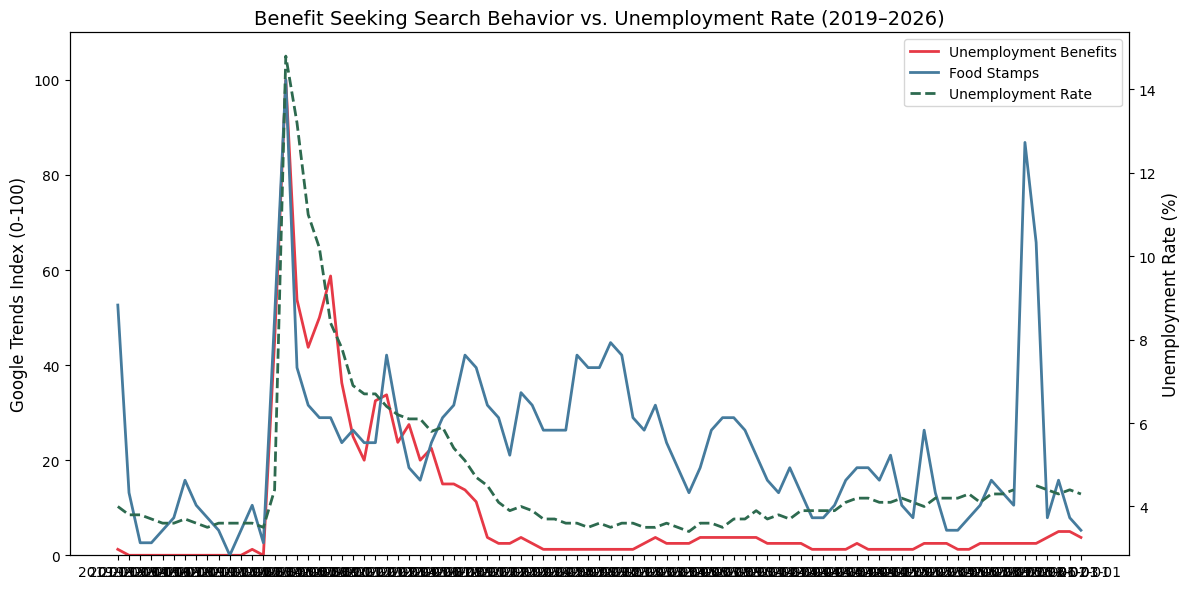

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(data['date'], data['unemployment benefits'], color='#e63946', linewidth=2, label='Unemployment Benefits')
ax1.plot(data['date'], data['food stamps'], color='#457b9d', linewidth=2, label='Food Stamps')
ax1.set_ylabel('Google Trends Index (0-100)', fontsize=12)
ax1.set_ylim(0, 110)

ax2 = ax1.twinx()
ax2.plot(data['date'], data['UNRATE'], color='#2d6a4f', linewidth=2, linestyle='--', label='Unemployment Rate')
ax2.set_ylabel('Unemployment Rate (%)', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.title('Benefit Seeking Search Behavior vs. Unemployment Rate (2019–2026)', fontsize=14)
plt.tight_layout()
plt.show() #I used Claude for this to help plot the lines across two different Y axes

Unsurprisingly, all three lines peak in early 2020 during COVID, then fall back toward their baselines as conditions stabilized. Searches for unemployment benefits track the unemployment rate most closely. Food stamps searches are more volatile in this period but generally follow a similiar pattern.

This all suggests that the answer to question one is yes: benefit seeking search behavior does move alongside labor market erosion. The alignment during COVID is especially telling, revealing that when unemployment rises rapidly, people quickly begin seeking information about public assistance. The fact that searches return to baseline as unemployment also normalizes indicates that this relationship runs in both directions. Food stamp searches are less aligned with the unemployment rate but that may be because food stamps are used by lower income households who are affected by other economic conditions beyond the employment rate. 

So how do job seeking searches compares during this same period?

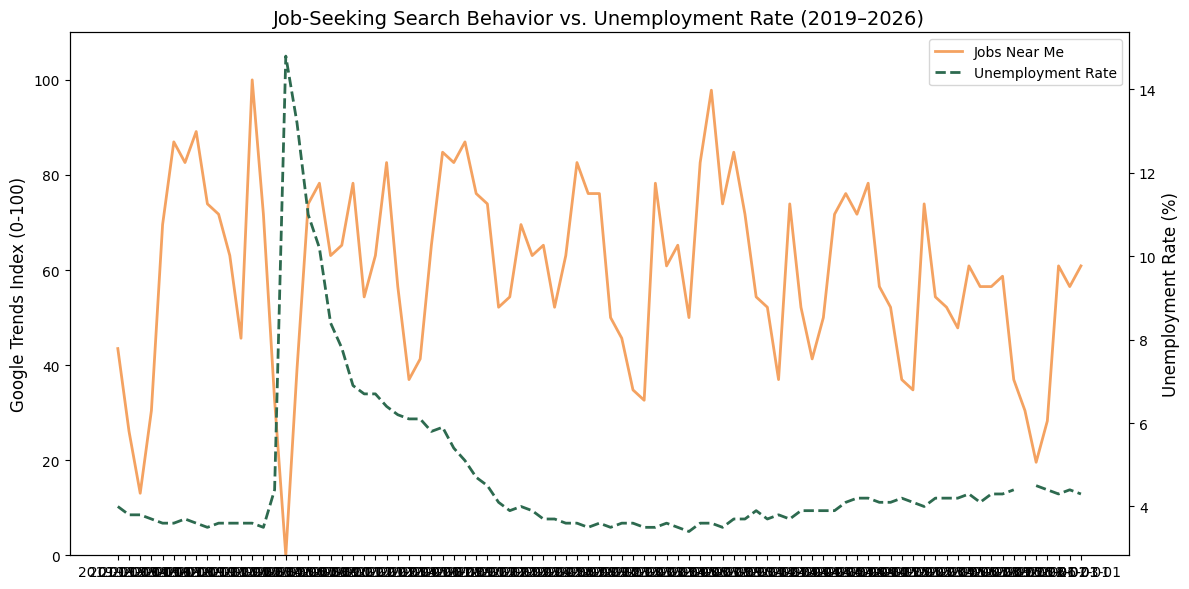

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(data['date'], data['jobs near me'], color='#f4a261', linewidth=2, label='Jobs Near Me')
ax1.set_ylabel('Google Trends Index (0-100)', fontsize=12)
ax1.set_ylim(0, 110)

ax2 = ax1.twinx()
ax2.plot(data['date'], data['UNRATE'], color='#2d6a4f', linewidth=2, linestyle='--', label='Unemployment Rate')
ax2.set_ylabel('Unemployment Rate (%)', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.title('Job-Seeking Search Behavior vs. Unemployment Rate (2019–2026)', fontsize=14)
plt.tight_layout()
plt.show()

Unlike the benefit seeking searches, "jobs near me" does not closely track the unemployment rate. While unemployment spikes dramatically during COVID and then gradually declines, searches for nearby jobs stay volatile throughout the entire period, with frequent rises and falls even during stable labor market conditions. Interestingly, searches for "jobs near me" plummet in early 2020 right when unemployment surges.

This suggests that job seeking search behavior does respond differently to economic shocks than benefit seeking behavior. While benefit related searches seem to reflect immediate economic distress, "jobs near me" searches may actually capture broader labor market *confidence* and optimism about employment opportunities. During COVID, economic uncertainty and widespread lockdowns likely reduced these searches since people knew that were very few available jobs. Thus, unlike unemployment benefits searches, job search behavior appears more independent of unemployment and influenced by a wider range of economic conditions and labor market sentiments. 

### Discussion

Initially, I assumed that in an economic downturn, looking for social benefits and looking for a job were somewhat synonymous behaviors. However, these findings indicate that benefit seeking and job seeking searches refelct very distinct orientations towards economic hardship. When unemployment rises sharply, people turn to the safety net evidenced by the closely aligned movement of searches for unemployment benefits and food stamps with the unemployment rate. In contrast, jobs near me searches are shaped less by distress and more by perceived opportunity, falling during times of uncertainty and expanding when conditions feel favorable. In this way, benefit seeking and job seeking searches seem to capture two distinct things: need and confidence. Understanding that distinction is important because it reveals that economic distress and economic disengagement (i.e. low searches for jobs) are not the same thing and conflating them risks mininterpreting what people need during a downturn.